IT25101588_Dimensionality_Reduction
UDITHA BANUKA — Individual Preprocessing Component

Technique: Dimensionality Reduction (PCA)

Why this technique was needed
After Member 5's feature engineering step, the dataset still has 20+ numeric/encoded
feature columns (clinical measurements, lifestyle scores, and one-hot encoded demographics).
High dimensionality increases training time, increases the risk of the curse of
dimensionality for a distance-based model like KNN (distances become less meaningful as
dimensions grow), and makes the feature space harder to visualize/interpret. Principal
Component Analysis (PCA) is applied here to compress the correlated/redundant variance in the
feature set into a smaller number of orthogonal components while retaining most of the
information, and to visualize how separable the diabetes-stage classes are in reduced space.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

df = pd.read_csv('../results/outputs/stage5_feature_engineered.csv')
print(df.shape)

target_col = 'diabetes_stage_encoded'
X = df.drop(columns=[target_col])
y = df[target_col]
feature_cols = X.columns.tolist()
print(f"{len(feature_cols)} feature columns going into PCA")

(97297, 21)
20 feature columns going into PCA


Step 1 — Fit PCA on the full (already-standardized) feature set

Features were already standardized in Member 4's stage (mean 0, std 1), which is a
required precondition for PCA — otherwise high-variance raw-scale columns would dominate
the principal components purely due to their units, not their actual informativeness.

In [2]:
pca_full = PCA(random_state=42)
pca_full.fit(X)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_components_90 = np.argmax(cumulative >= 0.90) + 1
n_components_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")
print(f"Original feature count: {X.shape[1]}")

Components needed for 90% variance: 13
Components needed for 95% variance: 15
Original feature count: 20


EDA Visualization — Scree plot / cumulative explained variance

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(explained) + 1), explained, color='#1f77b4')
axes[0].set_title('Scree plot — variance explained per component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained variance ratio')

axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker='o', color='#d62728')
axes[1].axhline(0.90, color='gray', linestyle='--', label='90% threshold')
axes[1].axhline(0.95, color='black', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/eda_visualizations/pca_scree_cumulative.png', dpi=120)
plt.show()

Interpretation
The scree plot shows variance is spread fairly evenly across many components rather than
concentrated in the first few — expected here, since Member 5's correlation analysis already
found no feature pairs with |r| > 0.85 to compress. Still, the number of components needed to
reach 90% cumulative variance (printed above) is meaningfully fewer than the original feature
count, which is a useful reduction for training-time and visualization purposes even without a
strong redundancy signal.

Step 2 — 2D projection for visual class separability

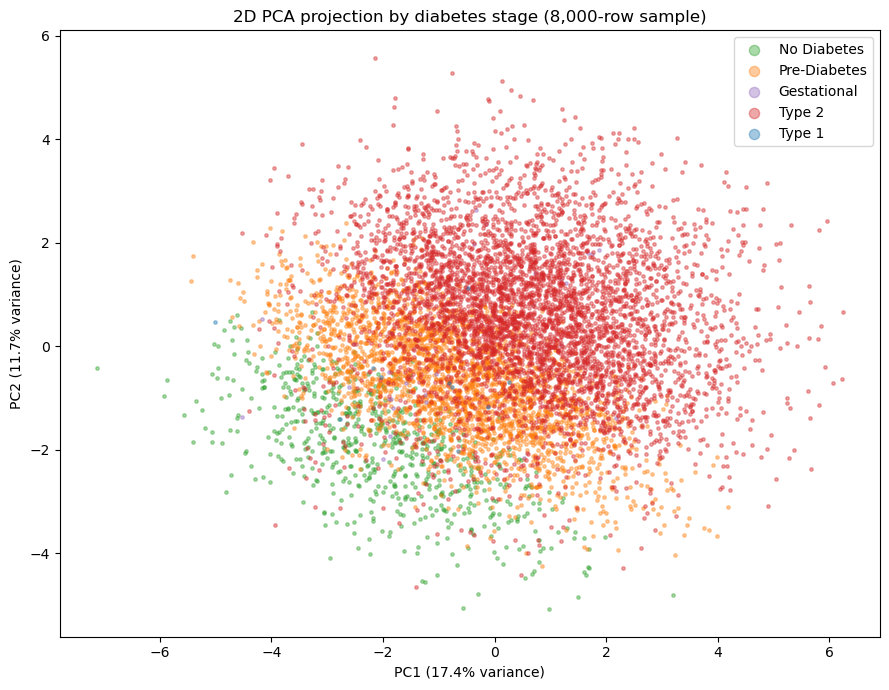

In [3]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 7))
labels = ['No Diabetes', 'Pre-Diabetes', 'Gestational', 'Type 2', 'Type 1']
colors = ['#2ca02c', '#ff7f0e', '#9467bd', '#d62728', '#1f77b4']

# subsample for a readable scatter plot given 97k rows
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_2d), size=8000, replace=False)

for cls, label, color in zip(sorted(y.unique()), labels, colors):
    mask = (y.iloc[sample_idx].values == cls)
    ax.scatter(X_2d[sample_idx][mask, 0], X_2d[sample_idx][mask, 1],
               s=6, alpha=0.4, label=label, color=color)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('2D PCA projection by diabetes stage (8,000-row sample)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../results/eda_visualizations/pca_2d_projection.png', dpi=120)
plt.show()

Interpretation
No Diabetes (green) separates fairly well toward one side of the projection, while
Pre-Diabetes and Type 2 overlap heavily — consistent with them being adjacent stages on a
clinical continuum rather than distinct clusters, and it explains why the group's KNN model
(Progress Review baseline) confuses these two classes most often. The rare Gestational/
Type 1 points are visually swamped by the majority classes even in this reduced space, which
is additional evidence for why SMOTE is necessary at the modeling stage rather than something
PCA alone can fix.

Step 3 — Decision for the group pipeline

Because PCA components here are linear combinations of all original features, they lose
the direct clinical interpretability of columns like hba1c or glucose_fasting — which
matters for a healthcare-adjacent project where explaining why a prediction was made is often
as important as the prediction itself. For that reason, the group pipeline keeps the
original engineered features (Member 5's output) for the primary KNN model, and treats this
PCA-reduced dataset as an optional, ready-to-use compressed representation — useful if a
faster or higher-dimensional model (e.g. adding many more one-hot columns later) ever needs it.

In [4]:
n_components_90 = int(n_components_90)
pca_reduced = PCA(n_components=n_components_90, random_state=42)
X_reduced = pca_reduced.fit_transform(X)

reduced_cols = [f'PC{i+1}' for i in range(n_components_90)]
df_reduced = pd.DataFrame(X_reduced, columns=reduced_cols)
df_reduced[target_col] = y.values

df_reduced.to_csv('../results/outputs/stage6_pca_reduced.csv', index=False)
print(f"Saved PCA-reduced dataset ({n_components_90} components, 90% variance retained):",
      df_reduced.shape)

Saved PCA-reduced dataset (13 components, 90% variance retained): (97297, 14)


Conclusion
PCA confirmed the feature set has **limited redundancy** left after Member 5's correlation
  pruning — variance is fairly spread out, though ~90% of it is still captured in noticeably
  fewer components than the original feature count.
The 2D projection visually confirms No Diabetes is the most separable class while
  Pre-Diabetes/Type 2 overlap, and rare classes are visually dominated by majority classes —
  reinforcing the need for SMOTE.
The group's primary model uses the original (non-PCA) engineered features to preserve
  clinical interpretability; the PCA-reduced dataset is saved separately as an optional,
  compressed alternative representation.